c:\Users\quzho2904\AppData\Local\anaconda3\envs\GEOF337\lib\site-packages\seabird\cnv.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



Station times:
2013: 2013-11-09 20:51
2014: 2014-10-05 15:10

===== Deep offset correction =====
Reference layer: deepest common 1 m
Bottom mean sigma0 (2013) = 27.313856
Bottom mean sigma0 (2014) = 27.310267
Offset applied to 2014 = 0.003589

Around 400 m (380–420 m):
Depth (m)     sigma0_2013     sigma0_2014_raw  sigma0_2014_aln  diff14-13
  380.00      27.312252      27.308809      27.312398     0.000146
  381.00      27.312268      27.308825      27.312414     0.000146
  382.00      27.312284      27.308841      27.312430     0.000146
  383.00      27.312300      27.308857      27.312446     0.000146
  384.00      27.312316      27.308873      27.312462     0.000146
  385.00      27.312332      27.308889      27.312478     0.000146
  386.00      27.312348      27.308905      27.312494     0.000146
  387.00      27.312364      27.308922      27.312510     0.000146
  388.00      27.312380      27.308938      27.312526     0.000146
  389.00      27.312396      27.308954      27.31254

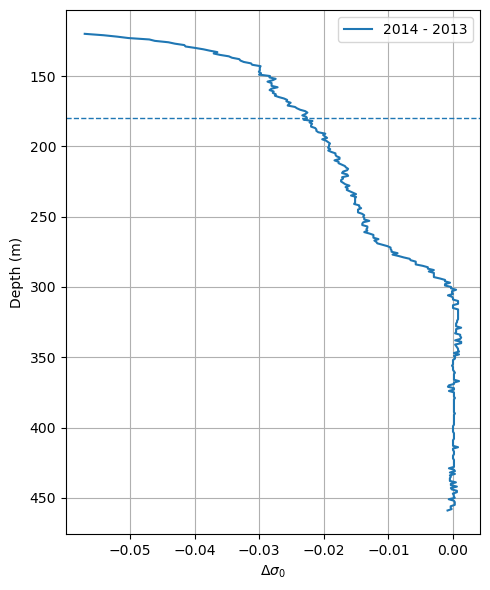

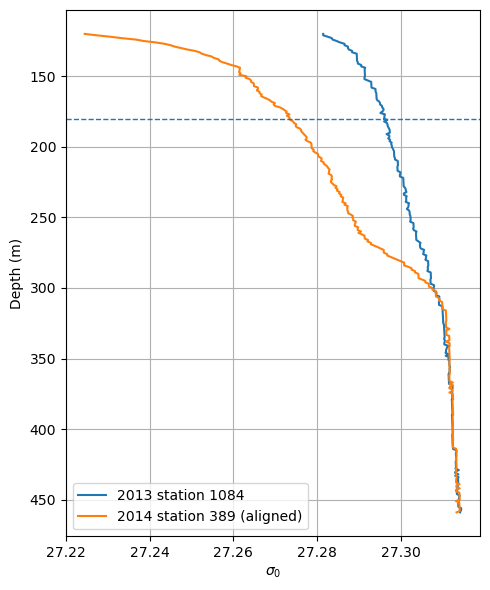

In [1]:
import GFPy.Ocean as Oc
import numpy as np
import gsw
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Read data
# =========================
file_2013 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\HM2013624.npy'
file_2014 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\GOS2014117.npy'

CTD_2013 = Oc.read_CTD(file_2013)
CTD_2014 = Oc.read_CTD(file_2014)

# =========================
# Unify LAT/LON field names
# =========================
for CTD in [CTD_2013, CTD_2014]:
    for st in CTD.keys():
        if 'lat' in CTD[st]:
            CTD[st]['LAT'] = CTD[st]['lat']
        if 'lon' in CTD[st]:
            CTD[st]['LON'] = CTD[st]['lon']

# =========================
# Compute TEOS-10 sigma0
# =========================
def compute_sigma0(CTD):
    for st in CTD.keys():
        S = np.asarray(CTD[st]['S'], dtype=float)
        T = np.asarray(CTD[st]['T'], dtype=float)
        z = np.asarray(CTD[st]['P'], dtype=float)

        lon = float(CTD[st]['LON'])
        lat = float(CTD[st]['LAT'])

        p = z.copy()

        n = min(len(S), len(T), len(p))
        S = S[:n]
        T = T[:n]
        p = p[:n]

        valid = np.isfinite(S) & np.isfinite(T) & np.isfinite(p)
        S = S[valid]
        T = T[valid]
        p = p[valid]

        SA = gsw.SA_from_SP(S, p, lon, lat)
        CT = gsw.CT_from_t(SA, T, p)

        CTD[st]['P'] = p
        CTD[st]['S'] = S
        CTD[st]['T'] = T
        CTD[st]['SIGTH'] = gsw.sigma0(SA, CT)

compute_sigma0(CTD_2013)
compute_sigma0(CTD_2014)

# =========================
# Helper: get station safely
# =========================
def get_station_data(CTD, station_id):
    if station_id in CTD:
        return CTD[station_id]
    if str(station_id) in CTD:
        return CTD[str(station_id)]
    raise KeyError(f"Station {station_id} not found. Available keys example: {list(CTD.keys())[:10]}")

# =========================
# Helper: get station datetime safely
# =========================
def get_station_time(st):
    for key in ["datetime", "time", "TIME"]:
        if key in st:
            return str(st[key])
    return "unknown"

# =========================
# Select stations
# =========================
station_2013_id = 1084
station_2014_id = 389

st2013 = get_station_data(CTD_2013, station_2013_id)
st2014 = get_station_data(CTD_2014, station_2014_id)

time_2013 = get_station_time(st2013)
time_2014 = get_station_time(st2014)

print("\nStation times:")
print("2013:", time_2013)
print("2014:", time_2014)

z1 = np.asarray(st2013['P'], dtype=float)
z2 = np.asarray(st2014['P'], dtype=float)

sig1 = np.asarray(st2013['SIGTH'], dtype=float)
sig2 = np.asarray(st2014['SIGTH'], dtype=float)

# =========================
# Direct truncation to common length
# =========================
n = min(len(sig1), len(sig2), len(z1), len(z2))

z_common = z1[:n]
sig1_common = sig1[:n]
sig2_common = sig2[:n]

# Raw difference
dsig_2014_minus_2013_raw = sig2_common - sig1_common

# =========================
# Deep alignment using deepest common 1 m
# =========================
bottom_window_m = 20.0
zmax_common = np.nanmax(z_common)
mask_bottom = z_common >= (zmax_common - bottom_window_m)

if np.sum(mask_bottom) < 1:
    raise ValueError("Not enough points in the deepest common 1 m for offset correction")

bottom_mean_2013 = np.nanmean(sig1_common[mask_bottom])
bottom_mean_2014 = np.nanmean(sig2_common[mask_bottom])

# Take 2013 as reference
offset_2014 = bottom_mean_2014 - bottom_mean_2013

# Align bottom values to 2013
sig1_aligned = sig1_common.copy()
sig2_aligned = sig2_common - offset_2014

# Recompute difference after alignment
dsig_2014_minus_2013 = sig2_aligned - sig1_aligned

print("\n===== Deep offset correction =====")
print("Reference layer: deepest common 1 m")
print(f"Bottom mean sigma0 (2013) = {bottom_mean_2013:.6f}")
print(f"Bottom mean sigma0 (2014) = {bottom_mean_2014:.6f}")
print(f"Offset applied to 2014 = {-offset_2014:.6f}")

# =========================
# Print selected depth range
# =========================
mask = (z_common >= 380) & (z_common <= 420)

print('\nAround 400 m (380–420 m):')
print('Depth (m)     sigma0_2013     sigma0_2014_raw  sigma0_2014_aln  diff14-13')

for i in np.where(mask)[0]:
    print(
        f'{z_common[i]:8.2f}   '
        f'{sig1_aligned[i]:12.6f}   '
        f'{sig2_common[i]:12.6f}   '
        f'{sig2_aligned[i]:12.6f}   '
        f'{dsig_2014_minus_2013[i]:10.6f}'
    )

if np.any(mask):
    print('\nStatistics in this depth range after alignment:')
    print('mean diff (2014-2013) =', np.nanmean(dsig_2014_minus_2013[mask]))
    print('max diff  (2014-2013) =', np.nanmax(dsig_2014_minus_2013[mask]))
    print('min diff  (2014-2013) =', np.nanmin(dsig_2014_minus_2013[mask]))
else:
    print('\nNo data points found in 380–420 m.')

# =========================
# Save sigma0 data
# =========================
save_csv = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station1084_2013_vs_station389_2014_aligned.csv'
save_npy = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station1084_2013_vs_station389_2014_aligned.npy'

df_save = pd.DataFrame({
    'depth_m': z_common,
    'sigma0_2013_raw': sig1_common,
    'sigma0_2014_raw': sig2_common,
    'sigma0_2013_aligned': sig1_aligned,
    'sigma0_2014_aligned': sig2_aligned,
    'sigma0_diff_2014_minus_2013_raw': dsig_2014_minus_2013_raw,
    'sigma0_diff_2014_minus_2013': dsig_2014_minus_2013,
    'datetime_2013': time_2013,
    'datetime_2014': time_2014
})

df_save.to_csv(save_csv, index=False, encoding='utf-8-sig')

save_dict = {
    'depth_m': z_common,
    'sigma0_2013_raw': sig1_common,
    'sigma0_2014_raw': sig2_common,
    'sigma0_2013_aligned': sig1_aligned,
    'sigma0_2014_aligned': sig2_aligned,
    'sigma0_diff_2014_minus_2013_raw': dsig_2014_minus_2013_raw,
    'sigma0_diff_2014_minus_2013': dsig_2014_minus_2013,
    'bottom_mean_2013': bottom_mean_2013,
    'bottom_mean_2014': bottom_mean_2014,
    'offset_2014_relative_to_2013': offset_2014,
    'station_2013_id': station_2013_id,
    'station_2014_id': station_2014_id,
    'datetime': {
        '2013': time_2013,
        '2014': time_2014
    }
}

np.save(save_npy, save_dict)

print(f'\nSaved csv to:\n{save_csv}')
print(f'Saved npy to:\n{save_npy}')

# =========================
# Plot sigma0 difference profile
# =========================
mask_deep = z_common >= 120

plt.figure(figsize=(5, 6))
plt.plot(dsig_2014_minus_2013[mask_deep], z_common[mask_deep], label='2014 - 2013')
plt.axhline(180, linestyle='--', linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel(r'$\Delta \sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# =========================
# Plot aligned sigma0 profiles
# =========================
plt.figure(figsize=(5, 6))
plt.plot(sig1_aligned[mask_deep], z_common[mask_deep], label=f'2013 station {station_2013_id}')
plt.plot(sig2_aligned[mask_deep], z_common[mask_deep], label=f'2014 station {station_2014_id} (aligned)')

plt.axhline(180, linestyle='--', linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel(r'$\sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()